# CIBUSmod multi-processing example
This notebook privides an example of how to use multiple processes to run multiple scenarios/years faster.

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Set up scenario and modules

Instantiate a `Session` object and define scenarios in the same way as in the single-processing case. To make multi-processing work we need to instantiate the CIBUSmod modules and define the calculations in a separate file. Here we use `multi_proc.py` for this. This file defines a function `do_run()`  which performes the calculations. It is important that the `name` and `data_path` parameters to create `Session` object in `multi_proc.py` matches the `name` and `data_path` defined below in this notebook.

In [3]:
years = list(range(2020,2050+1,5))

# Create session
session = cm.Session(
    name = 'example_scenarios',
    data_path = '../data'
)

# Define scenarios
session.add_scenario(
    name = 'Base20',
    scenario_workbooks = 'example_bau',
    years = years
)

# Define scenarios
session.add_scenario(
    name = 'Sust50',
    scenario_workbooks = ['example_bau', 'example_org_circ'],
    years = years
)

A scenario with the name 'Base20' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'Sust50' already exists use .update_scenario() or .remove_scenario() instead.


### Run calculations
The code below initiates a process pool that executes the model runs. The `max_workers` paramter to `ProcessPoolExecutor()` defines the maximum number of concurrent processes. The ideal value for this will depend on the computer. The code will print a message every time a scenario run has finnished and if a scenario run fails it will print an error message.

In [4]:
# Import
from concurrent.futures import ProcessPoolExecutor, as_completed
from multi_proc import do_run
import traceback

# Create list of scenarios/years to run
runs = [(s,y) for s, y in session.iterate('all')]
runs
# runs = [('Sust50','2050')]

[('Base20', '2020'),
 ('Base20', '2025'),
 ('Base20', '2030'),
 ('Base20', '2035'),
 ('Base20', '2040'),
 ('Base20', '2045'),
 ('Base20', '2050'),
 ('Sust50', '2020'),
 ('Sust50', '2025'),
 ('Sust50', '2030'),
 ('Sust50', '2035'),
 ('Sust50', '2040'),
 ('Sust50', '2045'),
 ('Sust50', '2050')]

In [5]:
%%time

# Do the multi-processing
with ProcessPoolExecutor(max_workers=8) as executor:
    
    futures = {executor.submit(do_run, session, scn_year) : scn_year for scn_year in runs}

    for future in as_completed(futures):
    
        scn, year = futures[future]
           
        try:
            t = future.result()
        except Exception as ee:
            print(f'(!!!) {scn}, {year} failed with the exception: {ee}')
        else:
            m = int(t/60)
            s = int(round(t - m*60))
            
            print(f'{scn}, {year} finished successfully in {m}min {s}s')
                    

Base20, 2025 finished successfully in 4min 22s
Base20, 2020 finished successfully in 4min 36s
Base20, 2045 finished successfully in 4min 49s
Sust50, 2020 finished successfully in 4min 51s
Base20, 2050 finished successfully in 4min 55s
Base20, 2030 finished successfully in 4min 56s
Base20, 2035 finished successfully in 5min 4s
Base20, 2040 finished successfully in 5min 4s
Sust50, 2025 finished successfully in 3min 13s
Sust50, 2030 finished successfully in 3min 45s
Sust50, 2045 finished successfully in 3min 51s
Sust50, 2035 finished successfully in 3min 60s
Sust50, 2040 finished successfully in 4min 1s
Sust50, 2050 finished successfully in 4min 1s
CPU times: total: 0 ns
Wall time: 9min 4s


## Plot output
Here are some example output plots.

In [42]:
bar_style = {
    'ticklabels_fontsize' : 9,
    'grouplabels_fontsize' : 9,
    'ylabel_fontsize' : 10,
    'xlabel_fontsize' : 10,
    'cmap' : 'YlGnBu'
}

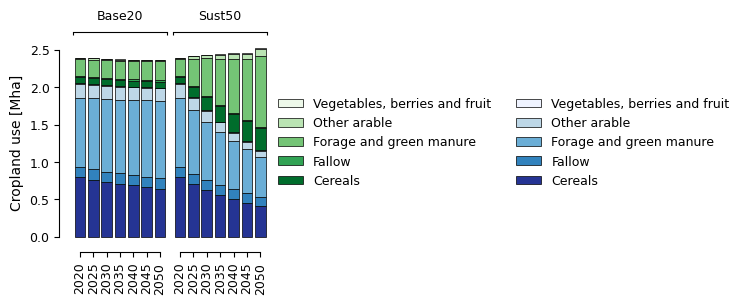

prod_system  conventional    organic
scn    year                         
Base20 2020     85.814624  14.185376
       2025     85.527159  14.472841
       2030     85.255995  14.744005
       2035     85.010627  14.989373
       2040     84.774128  15.225872
       2045     84.547250  15.452750
       2050     84.349275  15.650725
Sust50 2020     85.814959  14.185041
       2025     77.130795  22.869205
       2030     69.581688  30.418312
       2035     63.008935  36.991065
       2040     57.163447  42.836553
       2045     51.962577  48.037423
       2050     46.036630  53.963370

In [43]:
plot_data = (
    session.get_attr('c','area',{'prod_system':None, 'crop':['land_use','crop_group2']})
    .loc[:,(slice(None),'cropland')]
    .droplevel('land_use', axis=1)
    .rename(columns={'Fodder crops':'Forage and green manure'})
)/1_000_000

from matplotlib.colors import ListedColormap
colors = ['#253494', '#3182bd', '#6baed6','#bdd7e7' , '#eff3ff',
          '#006d2c', '#31a354', '#74c476', '#bae4b3', '#edf8e9']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, ax = plt.subplots(figsize=(2.5,2.5))
cm.plot.bar(
    plot_data.droplevel('prod_system', axis=1),
    ax=ax,
    group_levels='scn',
    sort_categories=False,
    ylabel='Cropland use [Mha]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap
)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=2, fontsize=9, frameon=False, reverse=True)
plt.show()

display(plot_data.T.groupby('prod_system').sum().T.apply(lambda x: x/x.sum()*100, axis=1))

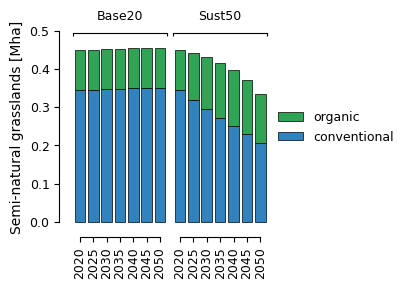

In [44]:
plot_data = (
    session.get_attr('c','area',{'prod_system':None, 'crop':'land_use'})
    .loc[:,(slice(None),'semi-natural grasslands')]
    .droplevel('land_use', axis=1)
)/1_000_000

from matplotlib.colors import ListedColormap
colors = ['#3182bd','#31a354']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, ax = plt.subplots(figsize=(2.5,2.5))
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    sort_categories=False,
    ylabel='Semi-natural grasslands [Mha]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap
)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, fontsize=9, frameon=False, reverse=True)
plt.show()

In [45]:
d = (
    session.get_attr('c','harvest',{'crop':['land_use',None],'prod_system':None})/
    session.get_attr('c','area',{'crop':['land_use',None],'prod_system':None})
).loc[[('Base20','2020'),('Base20','2050'),('Sust50','2050')],'cropland'] / 1_000

display(d.T.xs('conventional', level='prod_system', drop_level=False))
display(d.T.xs('organic', level='prod_system', drop_level=False))

scn                                                  Base20             \
year                                                   2020       2050   
crop                                prod_system                          
Apples                              conventional  18.349617  21.228135   
Barley, spring                      conventional   5.017222   5.979550   
Barley, winter                      conventional   6.376670   7.601222   
Beans, dry                          conventional   1.768469   1.768864   
Broad beans and horse beans, dry    conventional   3.290752   4.126376   
Buckwheat                           conventional   1.580422   1.594228   
Cabbages, cauliflowers and broccoli conventional  21.719118  27.101337   
Carrots                             conventional  67.419062  85.568317   
Cereals for fodder                  conventional   3.493201   3.497601   
Cucumbers                           conventional  62.166506  63.397853   
Currants                            conventional   1.481360   1.501738   
Energy grass                        conventional   4.027580   4.027127   
Fallow                              conventional   2.333532   2.331942   
Green manure                        conventional   4.806995   4.809530   
Hazelnuts                           conventional   0.953436   0.980949   
Herbs                               conventional   4.007669   5.101798   
Lettuce and spinach                 conventional  15.537258  19.694113   
Ley for fodder                      conventional   5.509389   5.524243   
Ley for grazing                     conventional   4.446253   4.477995   
Ley for seed                        conventional   0.650000   0.650000   
Ley not harvested                   conventional   3.972666   3.970792   
Maize (corn)                        conventional   6.100138   6.102494   
Maize for forage and silage         conventional  10.756862  10.729494   
Mixed cereals                       conventional   3.331334   3.302300   
Oats                                conventional   4.619917   5.748651   
Onions                              conventional  51.321895  65.067885   
Other berries                       conventional   1.698998   1.768338   
Other crops for fodder              conventional   4.337702   4.351511   
Other fruit                         conventional   4.564604   4.586003   
Other root vegetables               conventional  34.838654  43.986379   
Other vegetables                    conventional  14.950928  18.566057   
Pears                               conventional  15.677668  15.726270   
Peas, dry                           conventional   3.414730   4.271971   
Peas, green                         conventional   4.405796   4.422554   
Potatoes, starch                    conventional  45.159234  55.111682   
Potatoes, table                     conventional  38.306503  46.641823   
Pumpkins and squash                 conventional  27.267127  34.126383   
Rapeseed, spring                    conventional   1.837205   2.199539   
Rapeseed, winter                    conventional   3.553707   4.258567   
Rye                                 conventional   6.905359   8.624232   
Short rotation coppice              conventional   4.695393   4.694593   
Strawberries                        conventional   6.878584   6.888588   
Sugar beet                          conventional  76.519129  95.612341   
Triticale, spring                   conventional   3.314987   3.320352   
Triticale, winter                   conventional   5.759942   5.757613   
Walnuts                             conventional   1.026273   1.029620   
Wheat, spring                       conventional   4.630356   6.301381   
Wheat, winter                       conventional   7.248003   9.907214   

scn                                                   Sust50  
year                                                    2050  
crop                                prod_system               
Apples                              

scn                                              Base20                Sust50
year                                               2020       2050       2050
crop                             prod_system                                 
Apples                           organic       8.113651   8.108454   8.126362
Barley, spring                   organic       3.181706   3.281929   4.340499
Barley, winter                   organic       3.970397   4.088789   5.162277
Beans, dry                       organic       1.401294   1.695912   1.851646
Broad beans and horse beans, dry organic       2.361739   2.726260   3.454259
Buckwheat                        organic       1.291117        inf   0.798621
Carrots                          organic      58.646175  74.530517  80.351414
Cereals for fodder               organic       3.079960   3.078993   3.106777
Cucumbers                        organic      10.482327  13.310203  14.469690
Energy grass                     organic       3.570565   3.567664   3.545944
Fallow                           organic       2.240963   2.238527   2.271244
Green manure                     organic       4.500310   4.499721   4.955113
Hazelnuts                        organic       1.047401        inf   0.800040
Herbs                            organic       0.877410   1.113576   1.310205
Lettuce and spinach              organic       5.840186   7.418645   8.032365
Ley for fodder                   organic       4.729326   4.734524   4.785045
Ley for grazing                  organic       3.796983   3.819985   3.862028
Ley for seed                     organic       0.400000   0.400000   0.400000
Ley not harvested                organic       3.541791   3.542321   3.629984
Maize (corn)                     organic       3.941140   3.941336   3.934011
Mixed cereals                    organic       2.728909   2.749581   2.907646
Oats                             organic       2.999367   3.120454   4.196024
Onions                           organic      25.815639  32.789529  35.490637
Other crops for fodder           organic       3.579109   3.586035   3.609131
Other root vegetables            organic       7.245330   9.204441   9.928434
Other vegetables                 organic       3.170566   4.026040   4.315855
Pears                            organic       5.476809   5.474227   5.484679
Peas, dry                        organic       2.623294   3.032911   3.669859
Potatoes, starch                 organic            NaN        NaN  40.449402
Potatoes, table                  organic      26.005565  31.919454  35.122112
Rapeseed, spring                 organic       0.730705   0.967778   1.139799
Rapeseed, winter                 organic       2.134589   2.840946   3.294099
Rye                              organic       3.852909   5.405796   6.133855
Short rotation coppice           organic       4.475796   4.468859   4.471629
Triticale, spring                organic       2.109707   2.111032   2.135953
Triticale, winter                organic       4.230574   4.229025   4.118880
Walnuts                          organic       1.384921        inf   1.000000
Wheat, spring                    organic       2.913136   3.627006   4.308456
Wheat, winter                    organic       4.417085   5.508767   6.263661

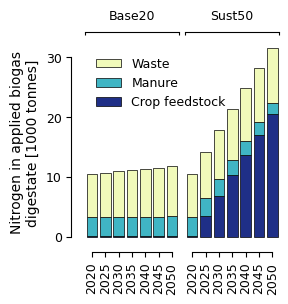

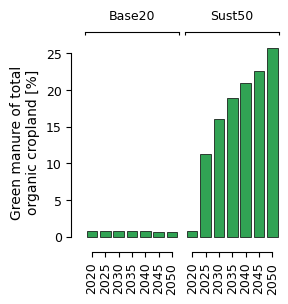

scn     year
Base20  2020     0.740598
        2025     0.728622
        2030     0.718018
        2035     0.708764
        2040     0.698909
        2045     0.688984
        2050     0.681103
Sust50  2020     0.737560
        2025    11.301690
        2030    16.043450
        2035    18.908948
        2040    20.938397
        2045    22.526475
        2050    25.744524
Name: Green manure, dtype: float64

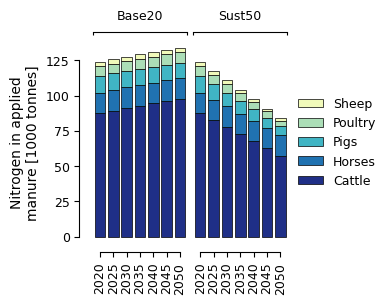

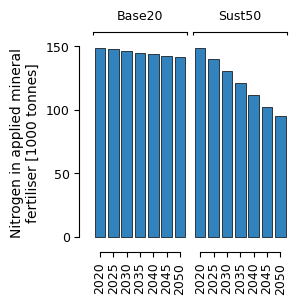

scn     year
Base20  2020    148.613299
        2025    147.354553
        2030    146.033500
        2035    144.664362
        2040    143.478943
        2045    142.405567
        2050    141.255964
Sust50  2020    148.613540
        2025    139.819546
        2030    130.357992
        2035    120.784993
        2040    111.350642
        2045    102.225896
        2050     94.662531
Name: value, dtype: float64

In [46]:
from matplotlib.colors import ListedColormap

plot_data = (
    session.get_attr('w','organic_fertiliser_N','feedstock_type')
    .rename(columns = lambda x: 'Waste' if 'waste' in x else x.capitalize())
    .T.groupby('feedstock_type').sum().T
)/1_000_000

fig, ax = plt.subplots(figsize=(2.5,2.5))
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Nitrogen in applied biogas\ndigestate [1000 tonnes]',
    **bar_style
)
plt.show()

plot_data = session.get_attr('c','area',{'prod_system':None,'crop':['land_use',None]}).loc[:,('organic','cropland')].apply(lambda x: x/x.sum()*100, axis=1).loc[:,'Green manure']

colors = ['#31a354']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, ax = plt.subplots(figsize=(2.5,2.5))
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Green manure of total\norganic cropland [%]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap
)
plt.show()

display(plot_data)

plot_data = (
    session.get_attr('c','fertiliser.manure_N','species')
    .rename(columns = lambda x: x.capitalize())
)/1_000_000

fig, ax = plt.subplots(figsize=(2.5,2.5))
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Nitrogen in applied\nmanure [1000 tonnes]',
    **bar_style
)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, fontsize=9, frameon=False, reverse=True)
plt.show()

plot_data = (
    session.get_attr('c','fertiliser.mineral_N','none')
)/1_000_000

colors = ['#3182bd']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, ax = plt.subplots(figsize=(2.5,2.5))
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Nitrogen in applied mineral\nfertiliser [1000 tonnes]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap
)
ax.legend().set_visible(False)
plt.show()
display(plot_data)



In [47]:
session.get_attr('c','fertiliser.mineral_N','prod_system').add(
    session.get_attr('c','fertiliser.manure_N','prod_system')+session.get_attr('c','fertiliser.organic_N','prod_system'),
    fill_value=0
)/1_000_000

prod_system  conventional    organic
scn    year                         
Base20 2020    250.676642  32.194631
       2025    251.122131  32.745944
       2030    251.292601  33.230048
       2035    251.228591  33.642914
       2040    251.432063  34.083281
       2045    251.777758  34.537883
       2050    251.864746  34.915981
Sust50 2020    250.679339  32.192172
       2025    227.292394  43.978807
       2030    206.458389  52.399080
       2035    187.644898  58.453691
       2040    170.886474  62.655958
       2045    155.808966  65.438102
       2050    141.750446  68.478868

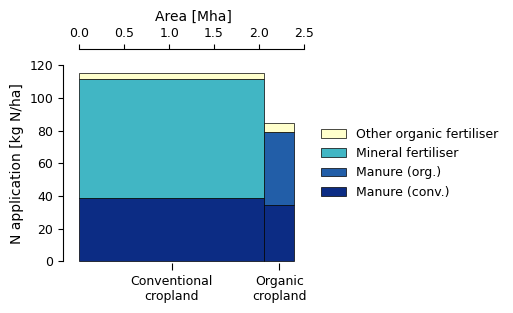

,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser,total
prod_system,,,,,
Conventional\ncropland,38.826143,0.269315,72.267548,4.147992,115.510999
Organic\ncropland,34.695511,44.539308,NaN,5.496536,84.731355


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser
prod_system,,,,
Conventional\ncropland,33.025192,0.229077,61.47017,3.528247
Organic\ncropland,40.784217,52.355500,NaN,6.461122


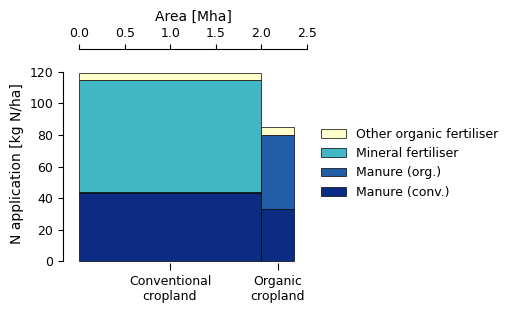

,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser,total
prod_system,,,,,
Conventional\ncropland,43.580008,0.293789,70.718722,4.893517,119.486036
Organic\ncropland,33.192085,46.515427,NaN,5.355206,85.062717


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser
prod_system,,,,
Conventional\ncropland,35.874012,0.241840,58.213947,4.028225
Organic\ncropland,38.851677,54.446785,NaN,6.268324


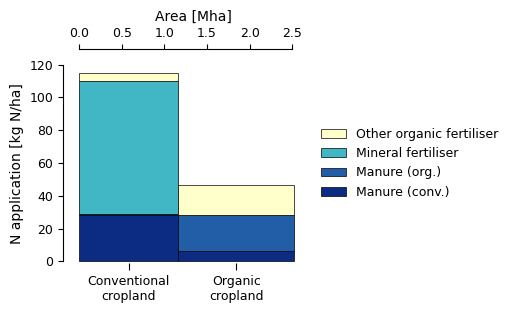

,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser,total
prod_system,,,,,
Conventional\ncropland,28.074691,0.580047,81.238085,5.241496,115.134318
Organic\ncropland,6.152667,21.963771,NaN,18.652858,46.769295


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser
prod_system,,,,
Conventional\ncropland,24.140425,0.498761,69.85373,4.506975
Organic\ncropland,12.782726,45.631738,NaN,38.753015


In [48]:
scn = 'SCN'

for scn, year in [('Base20','2020'),('Base20','2050'),('Sust50','2050')]:
    mi = (
        session.get_attr('c','fertiliser.mineral_N',{'crop':'land_use','prod_system':None}).loc[(scn,year),'cropland']
    )
    ma = (
        session.get_attr('c','fertiliser.manure_N',{'crop':'land_use','prod_system':None, 'animal_prod_system':None}).loc[(scn,year),'cropland']
        .unstack()
        .rename(columns={'conventional':'Manure (conv.)', 'organic':'Manure (org.)'})
    )
    
    oo = (
        session.get_attr('c','fertiliser.organic_N',{'crop':'land_use','prod_system':None}).loc[(scn,year),'cropland']
    )
    
    ar = (
        session.get_attr('c','area',{'crop':'land_use', 'prod_system':None}).loc[(scn,year),'cropland']
    )
    
    plot_data = pd.concat([
        ma.div(ar, axis=0),
        mi.div(ar, axis=0).rename('Mineral fertiliser'),
        oo.div(ar, axis=0).rename('Other organic fertiliser'),
        ar.rename('area')/1_000_000
    ], axis=1).rename(index={'conventional':'Conventional\ncropland','organic':'Organic\ncropland'})
    
    from matplotlib.colors import ListedColormap
    colors = ['#0c2c84', '#225ea8', '#41b6c4', '#ffffcc']
    cust_cmap = ListedColormap(name='X', colors=colors)
    
    fig, ax = plt.subplots(figsize=(3,2.6))
    
    cm.plot.marimekko(
        plot_data.fillna(0),
        ax=ax,
        x_column='area',
        cmap=cust_cmap,
        sort_categories=False,
        xlim_pad = 0.07,
        ylim_pad = 0.05,
        xcategorylabels_rotation=0,
        xcategorylabels_halign='center',
        ylabel='N application [kg N/ha]',
        xlabel='Area [Mha]',
        ylabel_fontsize=10,
        xlabel_fontsize=10,
        ticklabels_fontsize=9,
        xcategorylabels_fontsize=9
    )
    
    ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False, reverse=True)
    
    plt.show()
    fig.savefig(os.path.join(session.data_path_output,'figs',f'N-boxes {scn}_{year}.pdf'), format='pdf', bbox_inches="tight")

    table_data = plot_data.drop('area', axis=1)
    table_data['total'] = table_data.sum(axis=1)
    display(table_data)
    display(plot_data.div(plot_data.sum(axis=1), axis=0).drop('area', axis=1)*100)

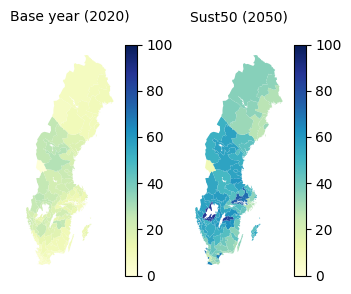

In [49]:
plot_data = (
    session.get_attr('c','area',{'crop':'land_use','region':None,'prod_system':None})
    .loc[:,'cropland']
    .T.groupby('region')
    .apply(lambda x: x/x.sum()*100).xs('organic', level='prod_system')
    .droplevel(0).T
)

fig, axs = plt.subplots(1,2, figsize=(4,3))

ax=axs[0]
cm.plot.map_from_series(
    plot_data.loc[('Sust50','2020')],
    vmin=0,
    vmax=100,
    cmap='YlGnBu',
    ax=ax
)
ax.axis('off')
ax.set_title('Base year (2020)', fontsize=10)

ax=axs[1]
cm.plot.map_from_series(
    plot_data.loc[('Sust50','2050')],
    vmin=0,
    vmax=100,
    cmap='YlGnBu',
    ax=ax
)
ax.axis('off')
ax.set_title('Sust50 (2050)', fontsize=10)

plt.show()

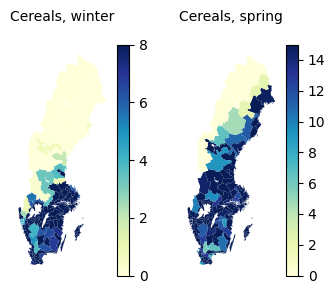

In [50]:
plot_data = (
    session.get_attr('c','area',{'crop':['land_use','crop_group'],'region':None,'prod_system':None})
    .xs(('cropland','organic'), level=('land_use', 'prod_system'), axis=1)
    .T.groupby('region')
    .apply(lambda x: x/x.sum()*100)
    .droplevel(0).T
)

fig, axs = plt.subplots(1,2, figsize=(4,3))

crp = 'Cereals, winter'
ax=axs[0]
cm.plot.map_from_series(
    plot_data.loc[('Sust50','2050'),crp],
    vmin=0,
    cmap='YlGnBu',
    ax=ax
)
ax.axis('off')
ax.set_title(crp, fontsize=10)

crp = 'Cereals, spring'
ax=axs[1]
cm.plot.map_from_series(
    plot_data.loc[('Sust50','2050'),crp],
    vmin=0,
    cmap='YlGnBu',
    ax=ax
)
ax.axis('off')
ax.set_title(crp, fontsize=10)

plt.show()

In [51]:
session.get_attr('c','fertiliser.crop_residues_N_soil_loss',['crop']).apply(lambda x: x/x.sum()*100, axis=1).loc[:,'Green manure']

scn     year
Base20  2020     0.151447
        2025     0.149551
        2030     0.147767
        2035     0.146143
        2040     0.144426
        2045     0.142711
        2050     0.141231
Sust50  2020     0.151084
        2025     2.946789
        2030     5.483369
        2035     7.780186
        2040     9.902138
        2045    11.873360
        2050    15.209183
Name: Green manure, dtype: float64

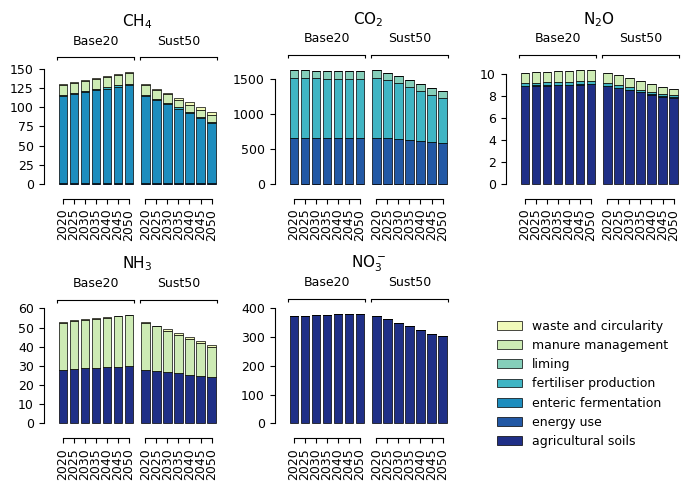

In [52]:
to_comp = {
    'CO2' : 1,
    'CH4bio' : 1,
    'CH4fos' : 1,
    'N2O' : 1,
    'N2O-N' : (44/28),
    'NH3-N' : (17/14),
    'NO3-N' : (62/14)
}

to_comp_names = {
    'N2O' : 'N$_2$O',
    'CO2' : 'CO$_2$',
    'CH4bio' : 'CH$_4$',
    'CH4fos' : 'CH$_4$',
    'N2O-N' : 'N$_2$O',
    'NH3-N' : 'NH$_3$',
    'NO3-N' : 'NO$_3^-$'
}

ems = (
    cm.get_emissions(session)
    .drop(['NOx-N','CO2bio','N2'], level='compound', axis=1)
)

plot_data = (
    ems
    .mul([to_comp[cp] for cp in ems.columns.get_level_values('compound')], axis=1)
    .rename(to_comp_names, axis=1)
    .T.groupby(['compound','process']).sum().T
    .stack().unstack().fillna(0)
)/1_000_000

fig, axs = plt.subplots(2,3, figsize=(7,5))
for i, cmp in enumerate(plot_data.columns.unique('compound')):
    ax = axs.flatten()[i]
    cm.plot.bar(
        plot_data.loc[:,cmp],
        group_levels='scn',
        ax=ax,
        **bar_style
    )
    ax.set_title(cmp, fontsize=11)

handles, labels = ax.get_legend_handles_labels()
ax = axs.flatten()[-1]
ax.legend(handles, labels, fontsize=9, frameon=False, reverse=True)
ax.axis('off')

for ax in axs.flatten()[:-1]:
    ax.legend().set_visible(False)

plt.tight_layout()
plt.show()

In [53]:
plot_data = (
    session.get_attr(
        module='D',
        attr='food_demand_to_processing',
        groupby=['origin','food_group']
    ).add(
        session.get_attr(
            module='D',
            attr='export_demand',
            groupby=['origin','food_group']
        ).rename(columns={'domestic':'exported'}),
        fill_value = 0
    )
    .stack()
    .fillna(0)
)/1000000
plot_data.loc[:,'imported'] = -plot_data.loc[:,'imported']
plot_data

origin                              domestic     exported    imported
scn    year food_group                                               
Base20 2020 alcoholic beverages   536.319440     0.000000 -336.144259
            cereals               538.216964  1305.993600 -228.836723
            dairy                1266.943959   524.202724 -181.244045
            eggs                  140.713683     0.000000   -3.608043
            fruits                 34.267570     0.000000 -121.514785
...                                      ...          ...         ...
Sust50 2050 sweeteners            144.990463     0.000000  -48.264857
            treenuts                0.000000     0.000000   -1.398227
            tubers                925.056252    25.000000 -176.201191
            vegetable oils         35.861717     0.000000 -103.790053
            vegetables            556.643346     0.000000 -689.922111

[182 rows x 3 columns]

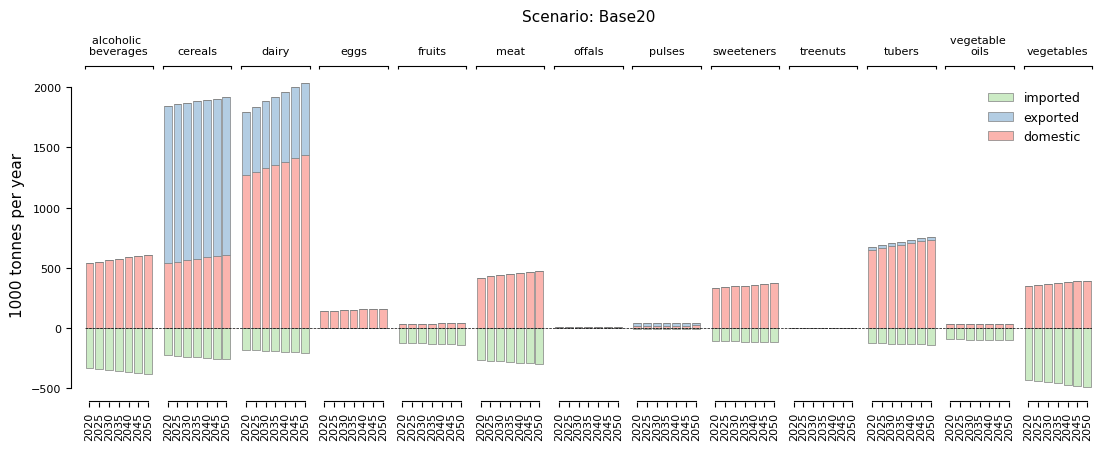

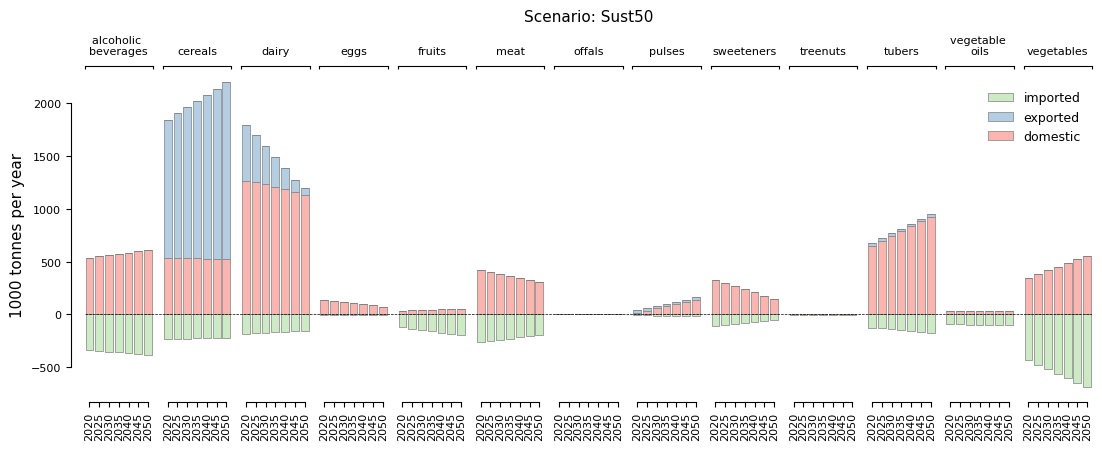

In [54]:
style = {
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey',
    'bar_width' : 0.8,
    'group_spacing' : 1,
    'grouplabels_fontsize' : 8,
    'ticklabels_fontsize' : 8,
    'totmarker' : 'none',
    'ylabel' : '1000 tonnes per year'
}
for scn in session.scenarios():
    fig, ax = plt.subplots(figsize=(13,4))
    cm.plot.bar(plot_data.loc[scn], group_levels='food_group', grouptitle=f'Scenario: {scn}', ax=ax, **style)
    plt.show()

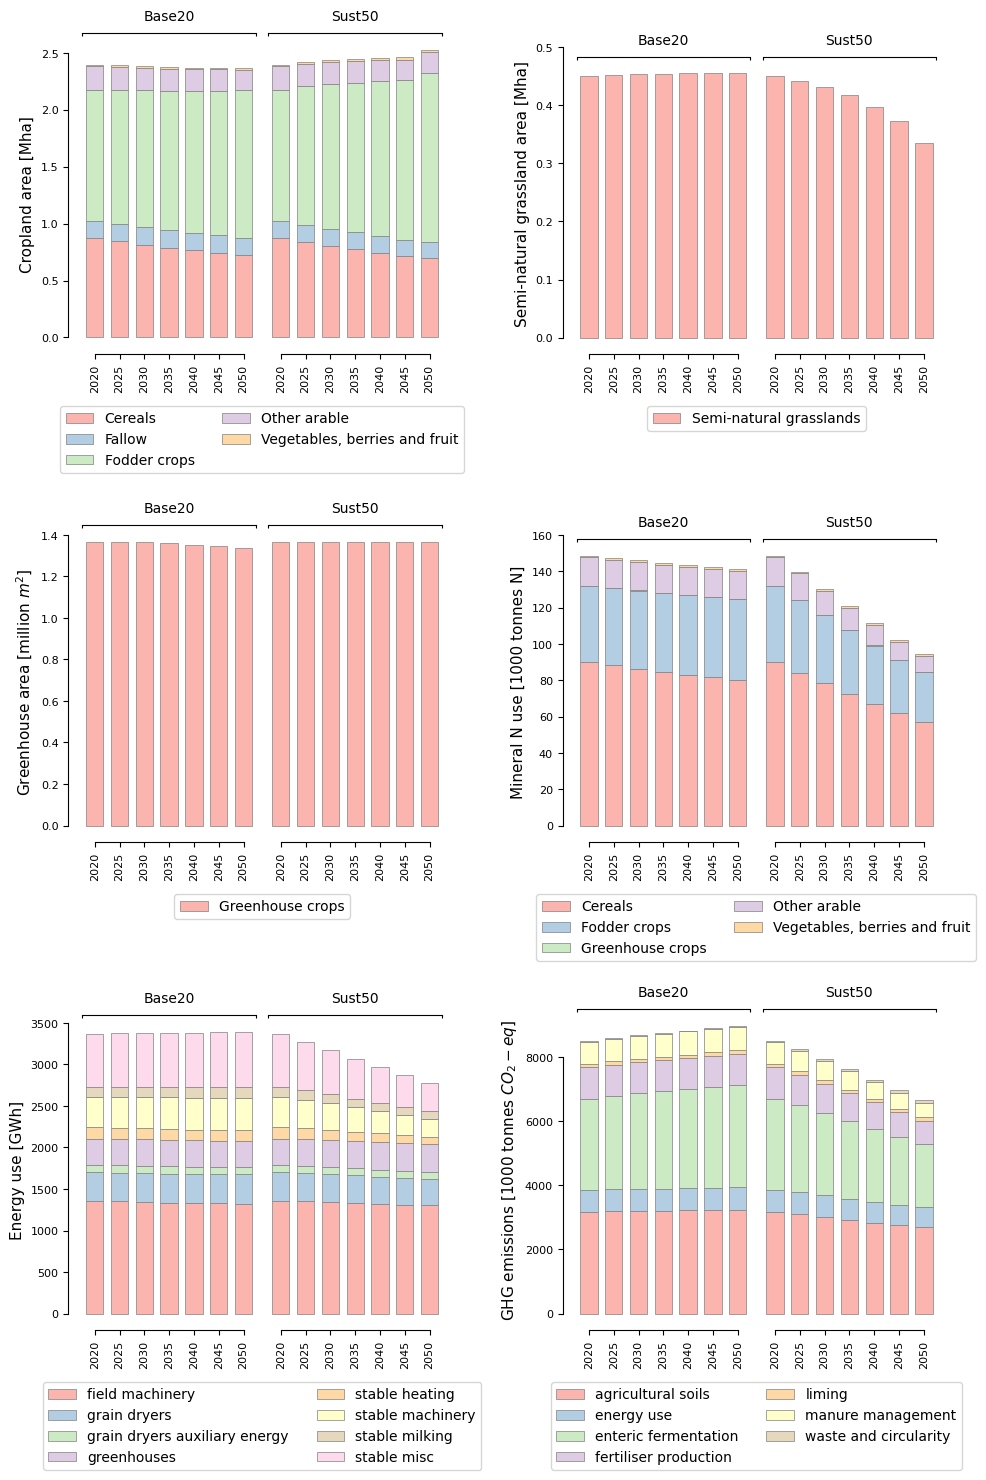

In [45]:
style = {
    'stacked' : True,
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey',
    'ticklabels_fontsize' : 8,
    'bar_width' : 0.7
}

fig, axs = plt.subplots(3,2, figsize=(10,15))

# Land use --->
plot_data = session.get_attr('C','area',{'crop':'crop_group2'})/1000000

# Cropland
ax = axs[0,0]
plot.bar(
    plot_data.drop(['Semi-natural grasslands','Greenhouse crops'], axis=1),
    **style,
    ax=ax,
    group_levels='scn',
    ylabel='Cropland area [Mha]'
)

# Semi-natural grassland
ax = axs[0,1]
plot.bar(
    plot_data.xs('Semi-natural grasslands', axis=1),
    **style,
    ax=ax,
    group_levels='scn',
    ylabel='Semi-natural grassland area [Mha]'
)

# Greenhouse
ax = axs[1,0]
plot.bar(
    plot_data.xs('Greenhouse crops', axis=1),
    **style,
    ax=ax,
    group_levels='scn',
    ylabel=r'Greenhouse area [million $m^2$]'
)

# Mineral N use --->
ax = axs[1,1]
plot.bar(
    (session.get_attr('C','fertiliser.mineral_N',{'crop':'crop_group2'})/1000000),
    **style,
    ax=ax,
    group_levels='scn',
    ylabel='Mineral N use [1000 tonnes N]'
)

# Energy use --->
ax = axs[2,0]
plot.bar(
    pd.concat([
        session.get_attr('C','energy_use','activity'),
        session.get_attr('A','energy_use','activity')
    ], axis=1)/1000000,
    **style,
    ax=ax,
    group_levels='scn',
    ylabel='Energy use [GWh]'
)

# GHG emissions
ax = axs[2,1]
plot_data = (
    cm.get_GHG(session)
    .T.groupby('process').sum().T
)/1000000
plot.bar(
    plot_data,
    **style,
    ax=ax,
    group_levels='scn',
    ylabel=r'GHG emissions [1000 tonnes $CO_{2}-eq$]'
)

for ax in axs.flatten():
    ax.legend(loc='upper center', ncol=2, bbox_to_anchor=(0.5, -0.2), fontsize=10)

plt.tight_layout()
plt.show()

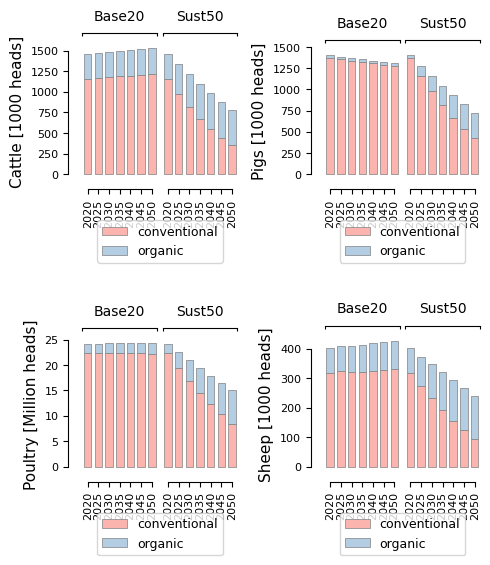

CPU times: total: 1.06 s
Wall time: 1.39 s


In [34]:
%%time
style = {
    'stacked' : True,
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey',
    'ticklabels_fontsize' : 8,
    'bar_width' : 0.7,
    
}
    
# Number of animal heads
plot_data = session.get_attr('A','heads',['species','prod_system'])

fig, axs = plt.subplots(2,2, figsize=(5,6))

for ax,sp in zip(axs.flatten(),plot_data.drop('horses', axis=1).columns.get_level_values('species').unique()):

    plot.bar(
        (plot_data / (1000000 if sp=='poultry' else 1000))
        .xs(sp, level='species', axis=1),
        **style,
        ax=ax,
        group_levels='scn',
        ylabel=sp.capitalize() + (' [Million heads]' if sp=='poultry' else ' [1000 heads]')
    )

    # ax.legend(loc='lower left', bbox_to_anchor=(0, 0))

for ax in axs.flatten():
    ax.legend(loc='upper center', ncol=1, bbox_to_anchor=(0.5, -0.3), fontsize=9)

plt.tight_layout()
plt.show()

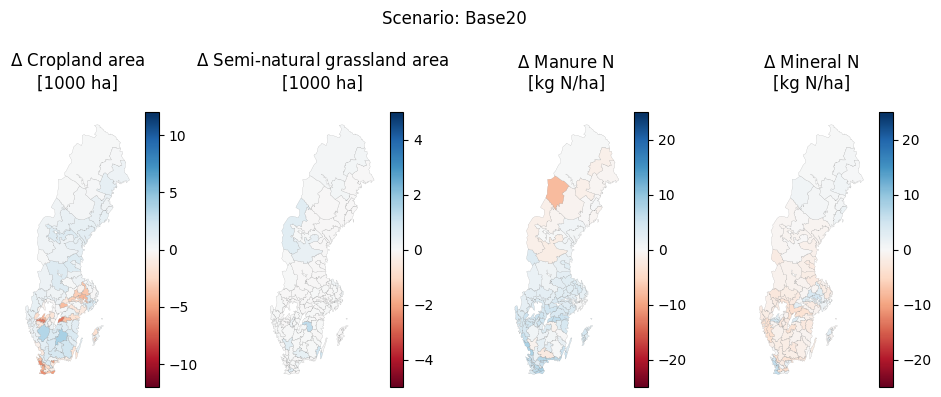

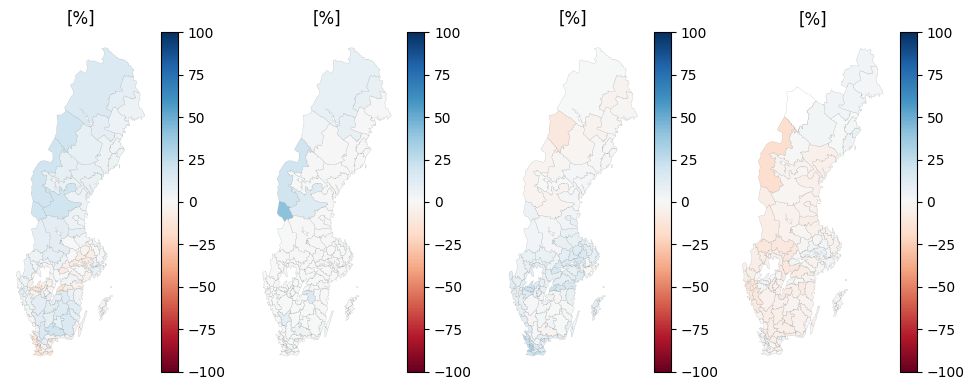

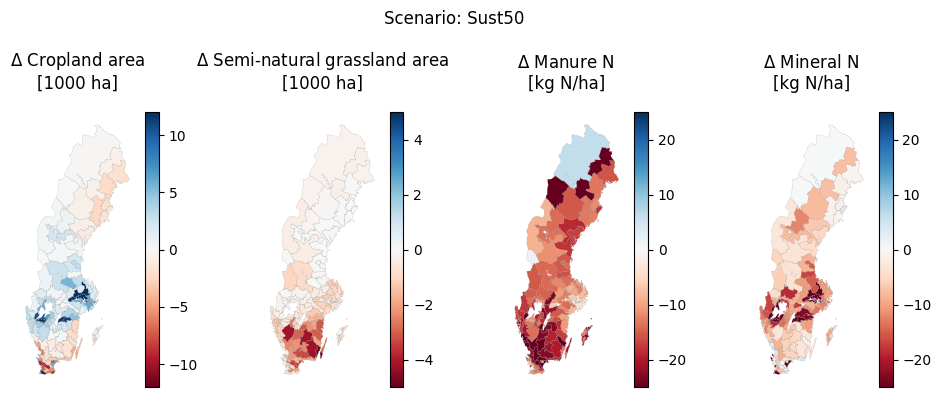

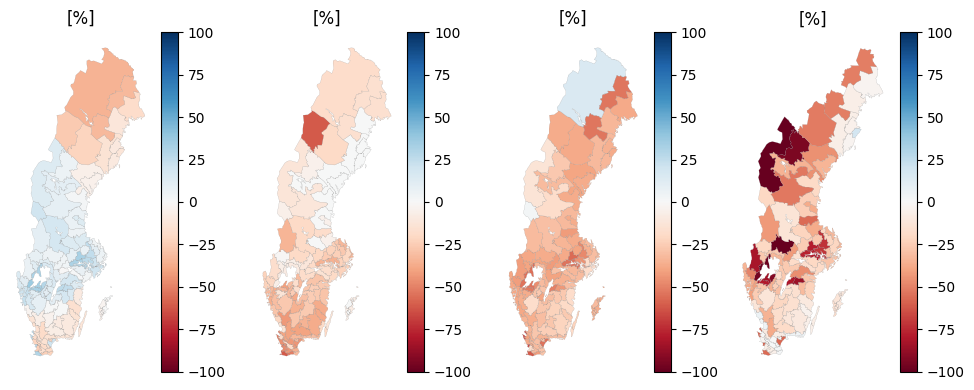

CPU times: total: 9.81 s
Wall time: 11.1 s


In [36]:
%%time
for scn in session.scenarios():
    
    y0 = session.scenarios()[scn][0]
    yend = session.scenarios()[scn][-1]

    # ABSOLUTE
    fig, axs = plt.subplots(1,4, figsize=(10,4))
    
    # LAND USE -------->
    plot_data = session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn]/1000
    plot_data = plot_data.loc[yend] - plot_data.loc[y0]
    # Cropland area --->
    ax = axs[0]
    plot.map_from_series(
        plot_data.loc['cropland'],
        cmap='RdBu',
        vmin=-12,
        vmax=12,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Cropland area\n[1000 ha]')
    ax.set_axis_off()

    # Grassland area --->
    ax = axs[1]
    plot.map_from_series(
        plot_data.loc['semi-natural grasslands'],
        cmap='RdBu',
        vmin=-5,
        vmax=5,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Semi-natural grassland area\n[1000 ha]')
    ax.set_axis_off()

    # Manure N application --->
    plot_data = session.get_attr('C','fertiliser.manure_N',{'crop':'land_use','region':None}).loc[scn,'cropland'] \
    / session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn,'cropland']
    plot_data = plot_data.loc[yend] - plot_data.loc[y0]
    
    ax = axs[2]
    plot.map_from_series(
        plot_data,
        cmap='RdBu',
        vmin=-25,
        vmax=25,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Manure N \n[kg N/ha]')
    ax.set_axis_off()

    # Mineral N application --->
    plot_data = session.get_attr('C','fertiliser.mineral_N',{'crop':'land_use','region':None}).loc[scn,'cropland'] \
    / session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn,'cropland']
    plot_data = plot_data.loc[yend] - plot_data.loc[y0]
    
    ax = axs[3]
    plot.map_from_series(
        plot_data,
        cmap='RdBu',
        vmin=-25,
        vmax=25,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Mineral N \n[kg N/ha]')
    ax.set_axis_off()

    
    plt.suptitle(f'Scenario: {scn}')
    plt.tight_layout()
    plt.show()

    # PERCENT
    fig, axs = plt.subplots(1,4, figsize=(10,4))
    
    # LAND USE -------->
    plot_data = session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn]/1000
    plot_data = (plot_data.loc[yend] - plot_data.loc[y0]) / plot_data.loc[y0] * 100
    # Cropland area --->
    ax = axs[0]
    plot.map_from_series(
        plot_data.loc['cropland'],
        cmap='RdBu',
        vmin=-100,
        vmax=100,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('[%]')
    ax.set_axis_off()

    # Grassland area --->
    ax = axs[1]
    plot.map_from_series(
        plot_data.loc['semi-natural grasslands'],
        cmap='RdBu',
        vmin=-100,
        vmax=100,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('[%]')
    ax.set_axis_off()

    # Manure N application --->
    plot_data = session.get_attr('C','fertiliser.manure_N',{'crop':'land_use','region':None}).loc[scn,'cropland'] \
    / session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn,'cropland']
    plot_data = (plot_data.loc[yend] - plot_data.loc[y0]) / plot_data.loc[y0] * 100
    
    ax = axs[2]
    plot.map_from_series(
        plot_data,
        cmap='RdBu',
        vmin=-100,
        vmax=100,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('[%]')
    ax.set_axis_off()

    # Mineral N application --->
    plot_data = session.get_attr('C','fertiliser.mineral_N',{'crop':'land_use','region':None}).loc[scn,'cropland'] \
    / session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn,'cropland']
    plot_data = (plot_data.loc[yend] - plot_data.loc[y0]) / plot_data.loc[y0] * 100
    
    ax = axs[3]
    plot.map_from_series(
        plot_data,
        cmap='RdBu',
        vmin=-100,
        vmax=100,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('[%]')
    ax.set_axis_off()
   
    
    plt.tight_layout()
    plt.show()

Base20
------


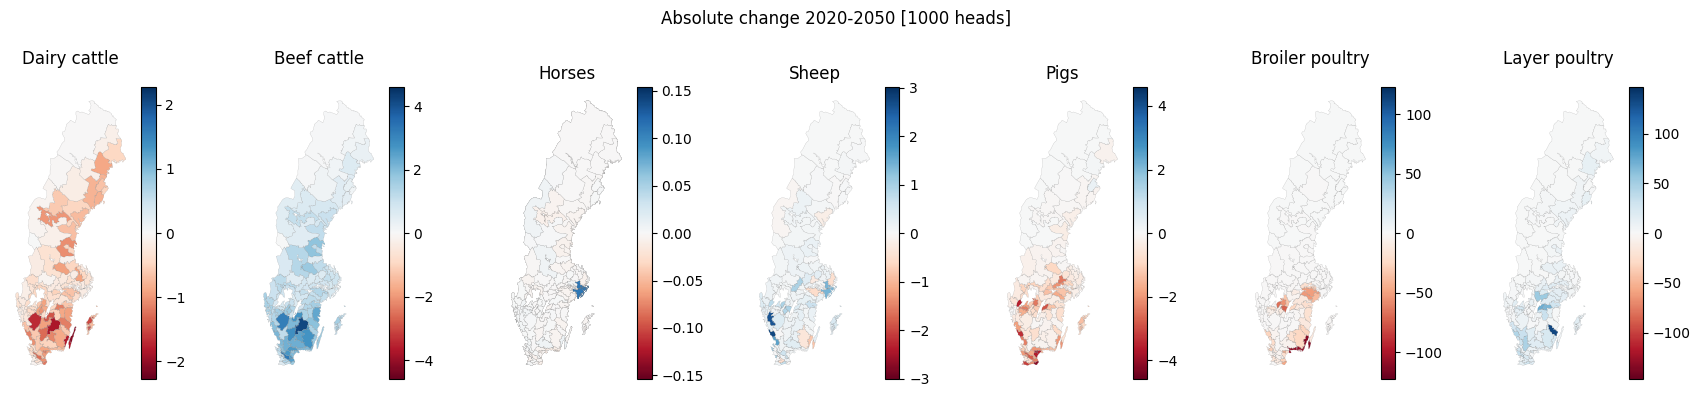

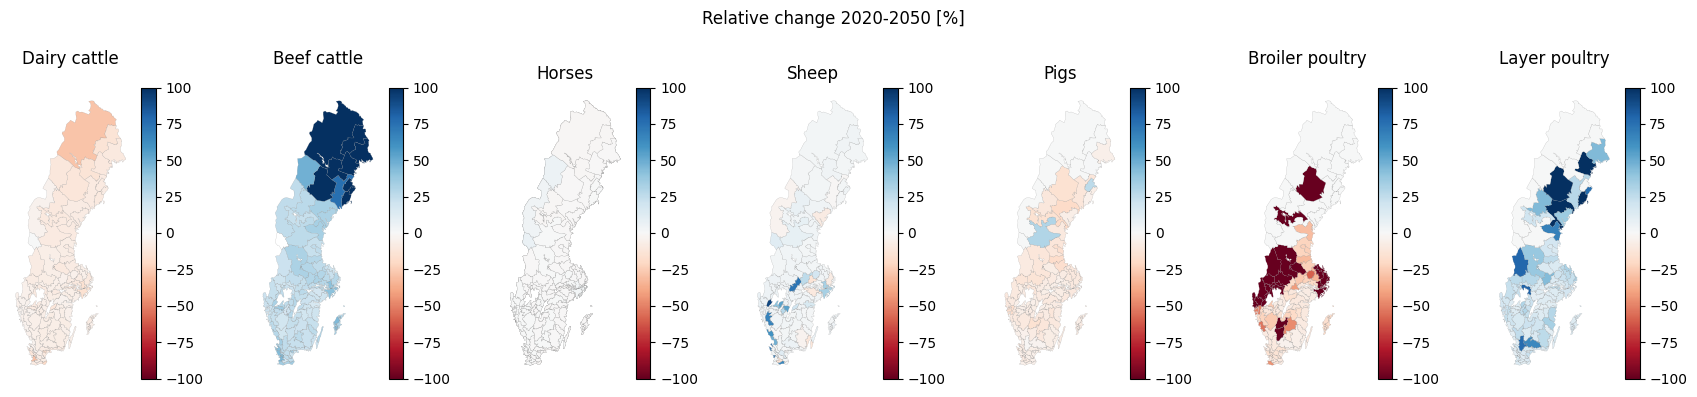

Sust50
------


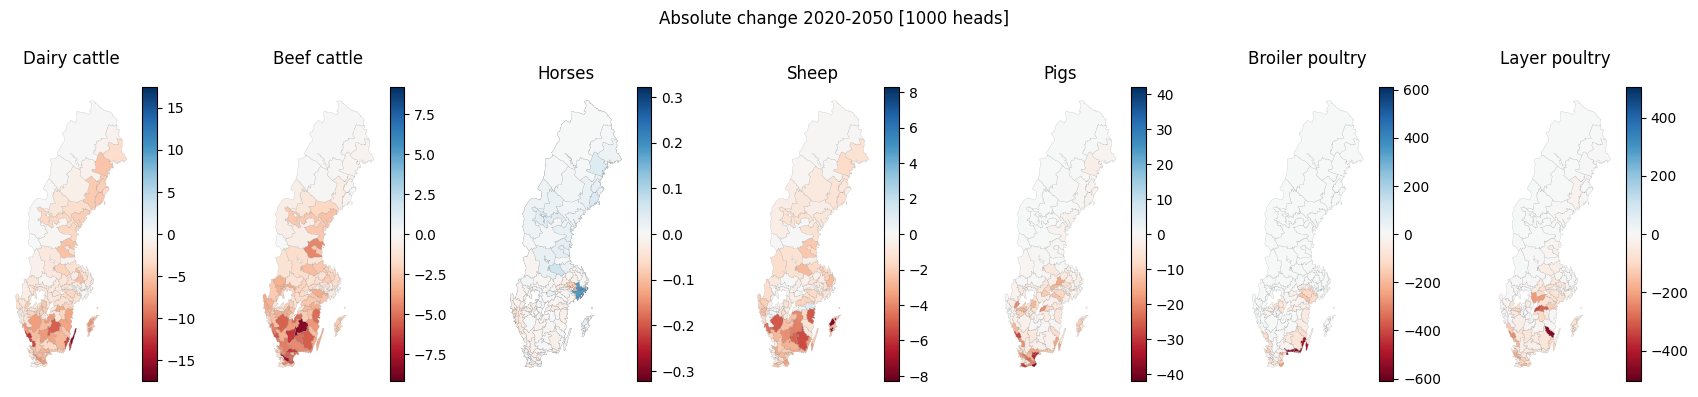

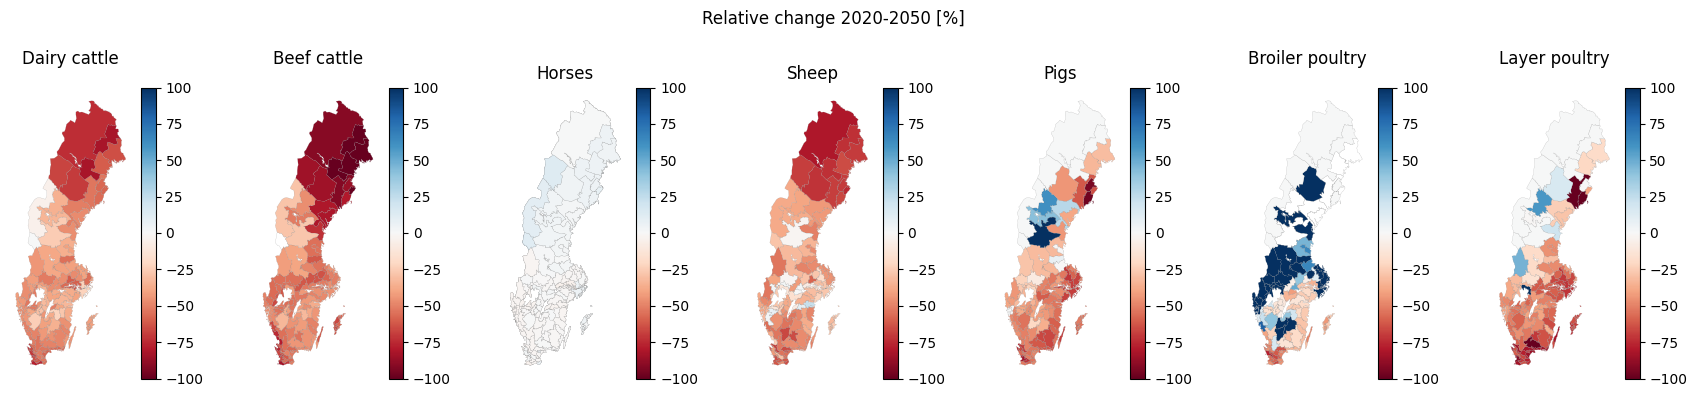

CPU times: total: 8.27 s
Wall time: 9.63 s


In [38]:
%%time
selection = {
    'Dairy cattle':('cattle','dairy'),
    'Beef cattle':('cattle','beef'),
    'Horses':('horses',slice(None)),
    'Sheep':('sheep',slice(None)),
    'Pigs':('pigs',slice(None)),
    'Broiler poultry':('poultry','broiler'),
    'Layer poultry':('poultry','layer')
}

for scn in session.scenarios():
    print(scn)
    print('-'*len(scn))
    
    plot_data = session.get_attr('A','heads',['species','breed','region']).loc[scn]/1000
    plot_data_abs = (plot_data.loc['2050'] - plot_data.loc['2020']).sort_index()
    plot_data_prc = ((plot_data.loc['2050'] - plot_data.loc['2020']) / plot_data.loc['2020'] * 100).sort_index().fillna(0)
    
    # ABSOLUTE
    fig, axs = plt.subplots(1,len(selection), figsize=(len(selection)*2.5,4))
    for ax,sel in zip(axs,selection):
        d = plot_data_abs.loc[selection[sel]]
        lim = max(abs(d))
        plot.map_from_series(
            d,
            ax=ax,
            cmap='RdBu',
            vmin=-lim*1.1,
            vmax=lim*1.1,
            edgecolor='grey'
        )
        ax.axis('off')
        ax.set_title(sel)  
    plt.suptitle('Absolute change 2020-2050 [1000 heads]')
    plt.tight_layout()
    plt.show()
    
    # PERCENT
    fig, axs = plt.subplots(1,len(selection), figsize=(len(selection)*2.5,4))
    for ax,sel in zip(axs,selection):
        d = plot_data_prc.loc[selection[sel]]
        lim = max(abs(d))
        plot.map_from_series(
            d,
            ax=ax,
            cmap='RdBu',
            vmin=-100,
            vmax=100,
            edgecolor='grey'
        )
        ax.axis('off')
        ax.set_title(sel)
    plt.suptitle('Relative change 2020-2050 [%]')
    plt.tight_layout()
    plt.show()

### Detailed changes across regions
Here are some plots that show how changes in the scenarios are distributed across regions by the optimisation algorithm implemented in the `GeoDistributor`.

Base20
------


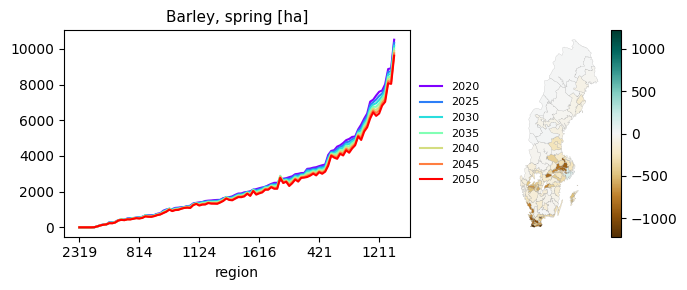

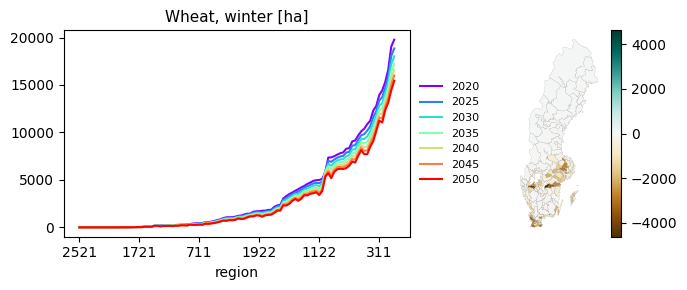

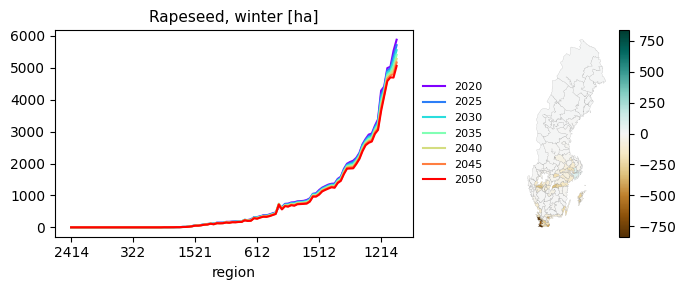

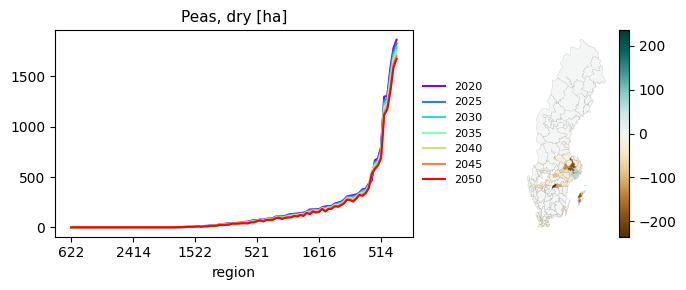

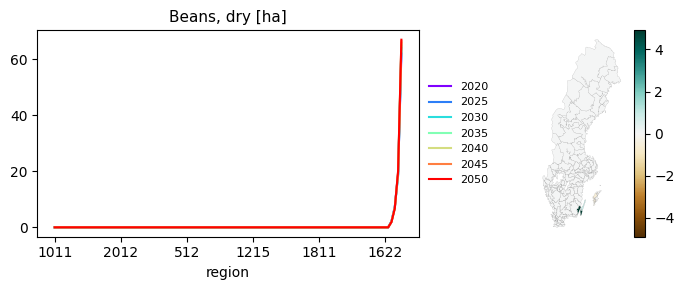

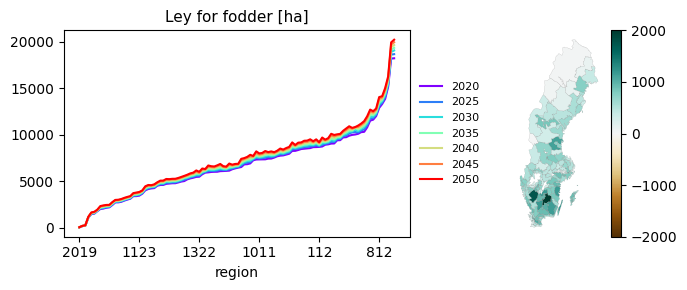

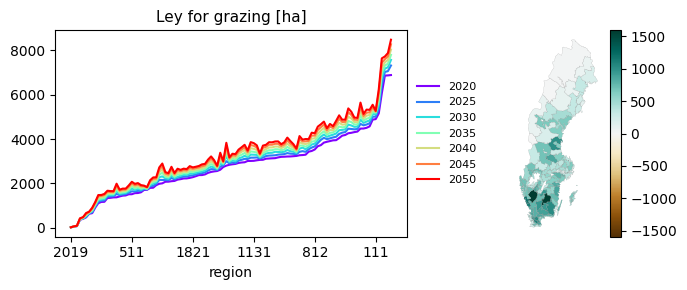

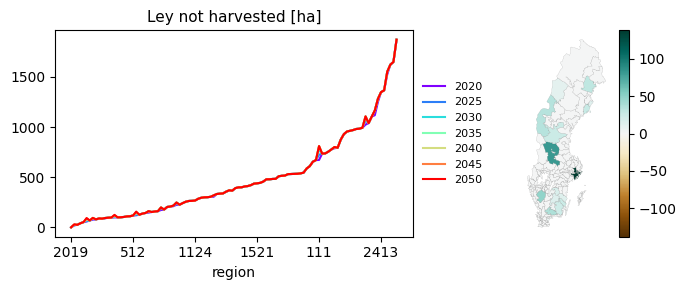

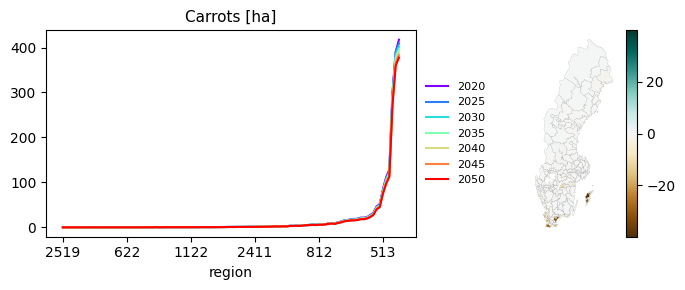

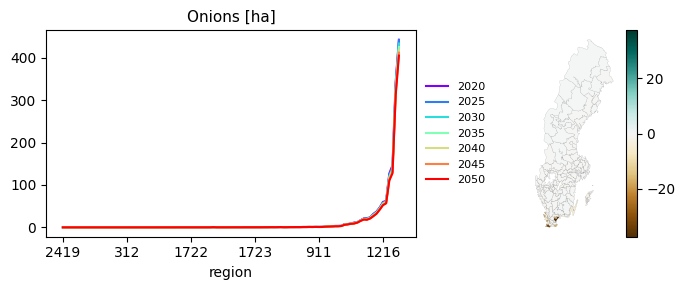

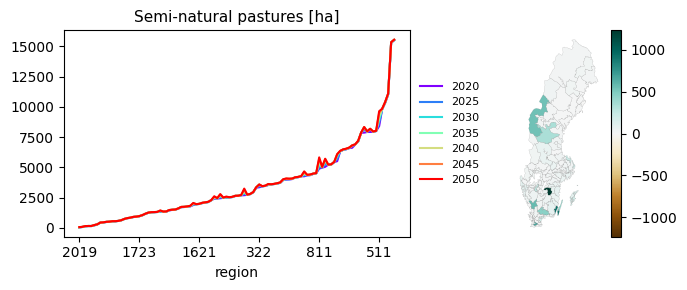

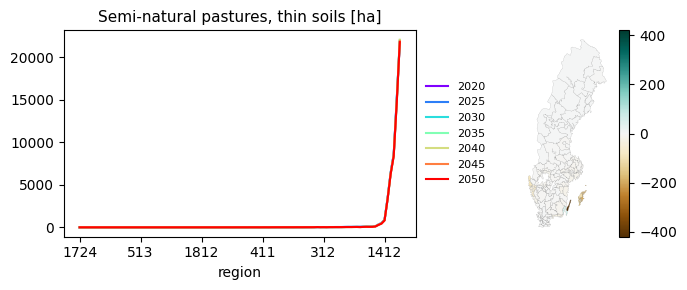

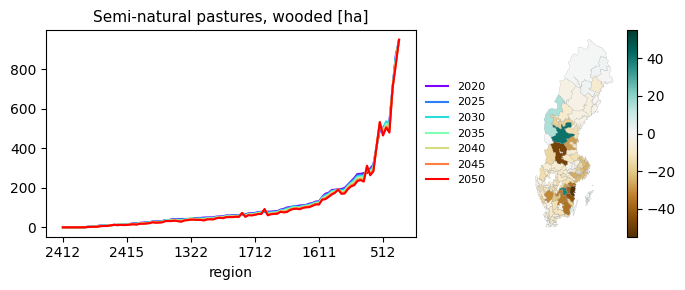

Sust50
------


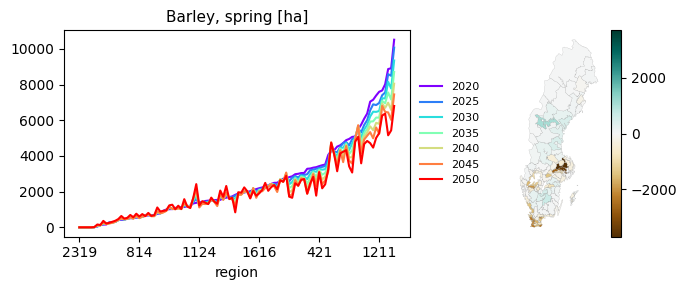

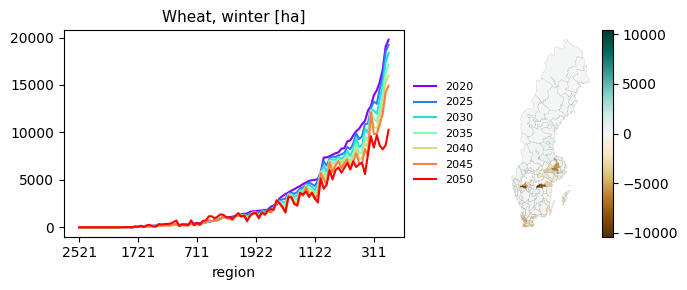

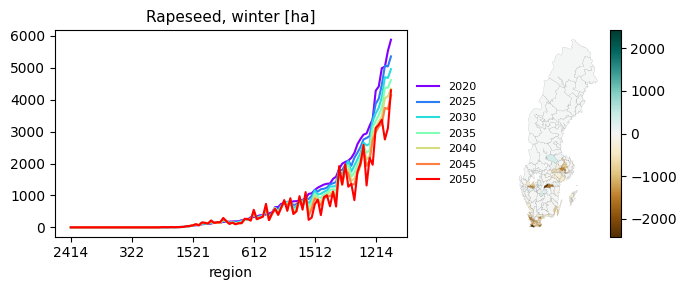

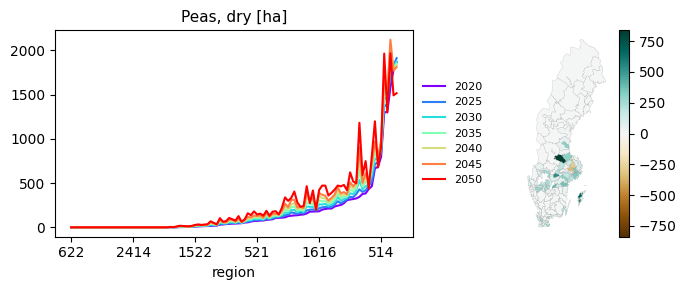

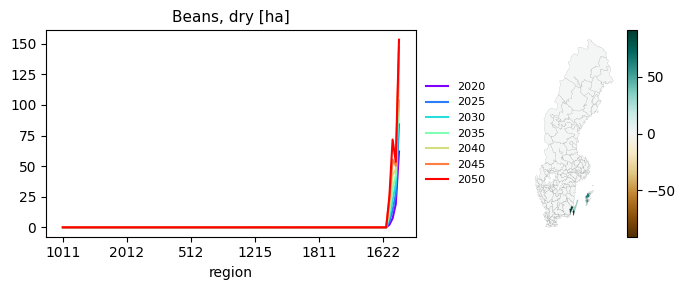

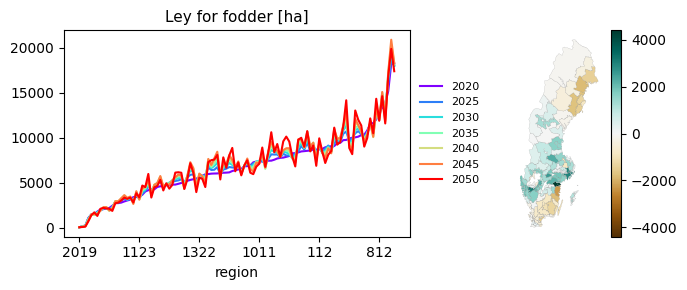

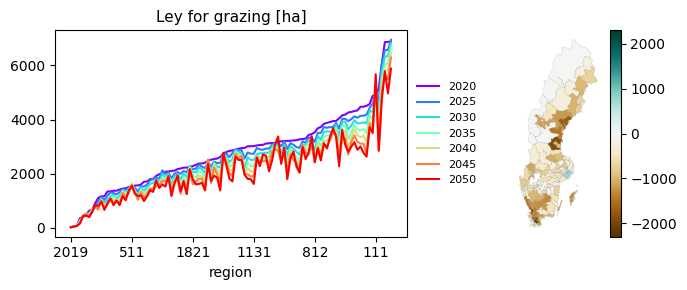

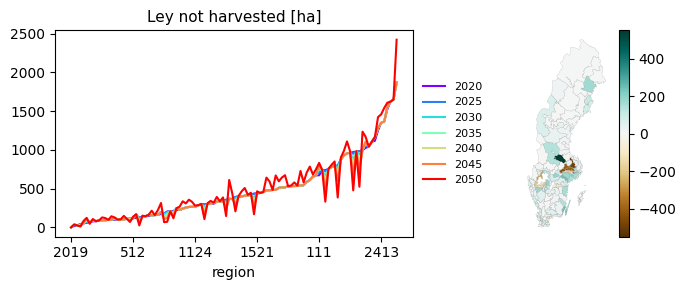

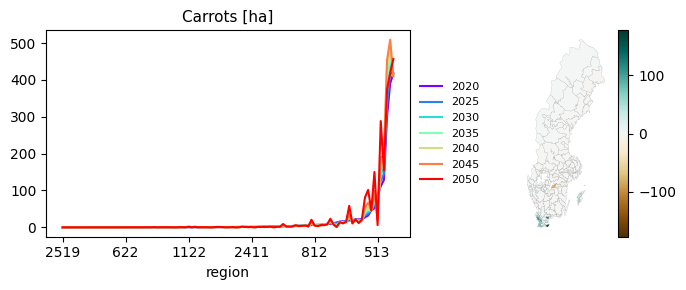

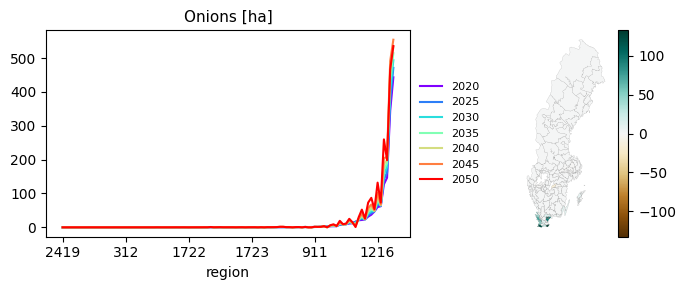

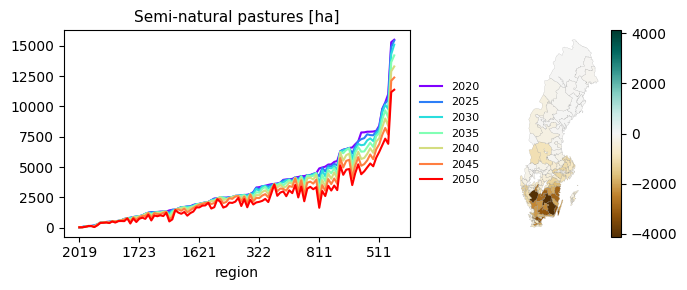

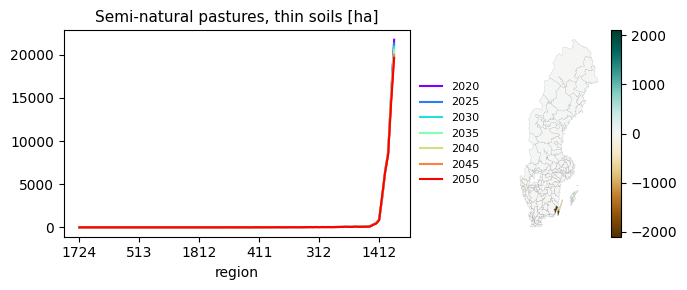

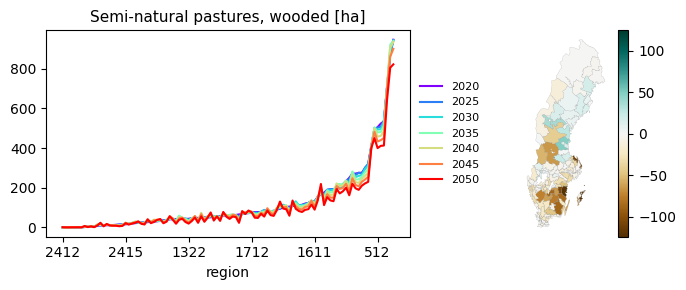

In [39]:
for scn in session.scenarios():
    print(scn)
    print('-'*len(scn))
    
    plot_data_ = session.get_attr('C','area',['crop','region'], scn=scn).droplevel('scn').T
    years = list(plot_data_.columns)
    crps = ['Barley, spring','Wheat, winter',
            'Rapeseed, winter',
            'Peas, dry', 'Beans, dry',
            'Ley for fodder','Ley for grazing', 'Ley not harvested',
            'Carrots','Onions',
            'Semi-natural pastures','Semi-natural pastures, thin soils','Semi-natural pastures, wooded']
    for crp in crps:
        plot_data = plot_data_.loc[crp].groupby('region').sum()
        plot_data['dif'] = (plot_data[years[-1]]-plot_data[years[0]])
        plot_data.sort_values(by=years[0], inplace=True)
    
        fig, axs = plt.subplots(1,2, figsize=(7,3), gridspec_kw={'width_ratios': [2, 1]})
        ax=axs[0]
        plot_data.plot(ax=ax, y=years, kind='line', marker='', linestyle='-', cmap='rainbow')
        # ax.set_yscale('log')
        ax.set_title(crp+' [ha]', size=11)
        ax.legend(loc='center left', ncols=1, bbox_to_anchor=(1, 0.5), frameon=False, fontsize=8)
    
        ax=axs[1]
        lim = max(abs(plot_data['dif']))
        plot.map_from_series(
            plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
            ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
        )
        ax.axis('off')
    
        plt.tight_layout()
        plt.show()

Base20
------


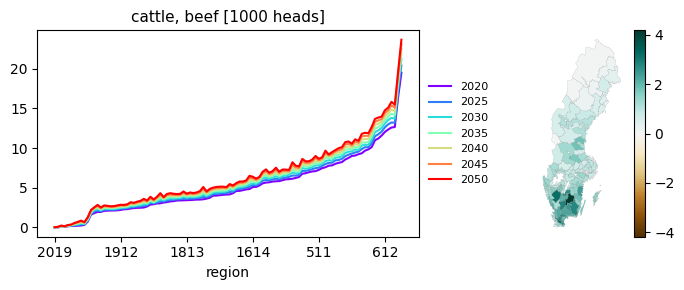

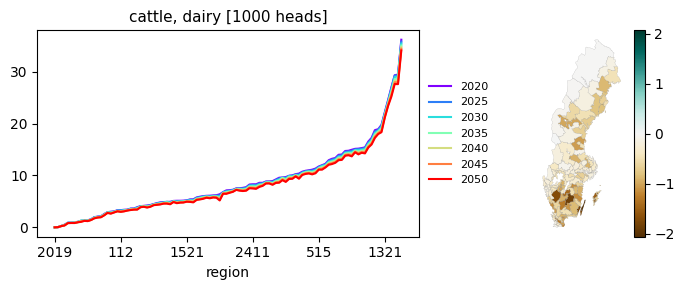

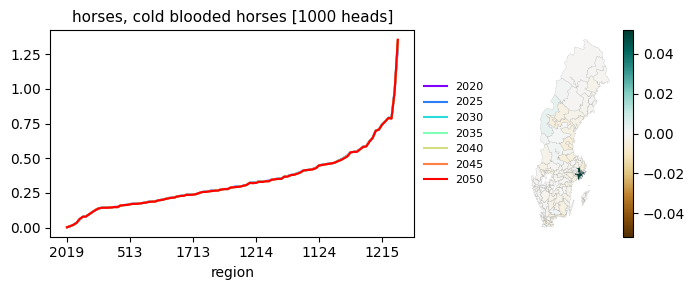

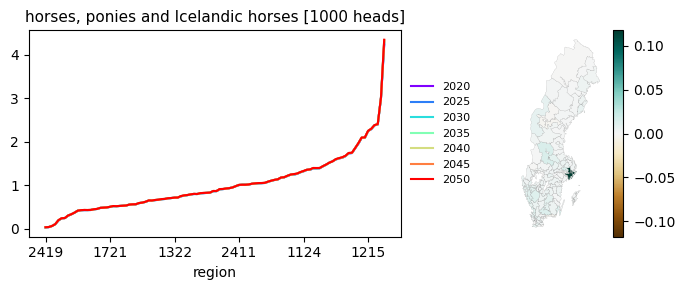

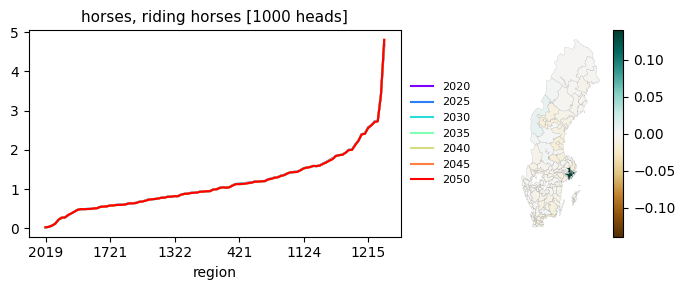

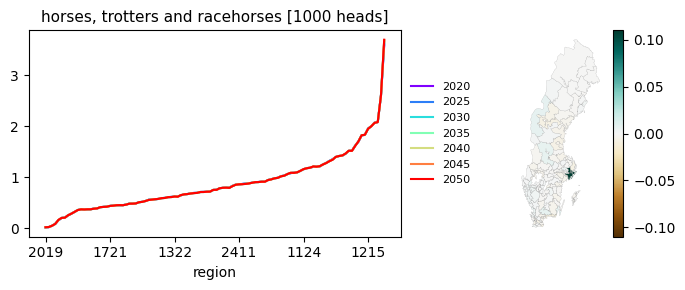

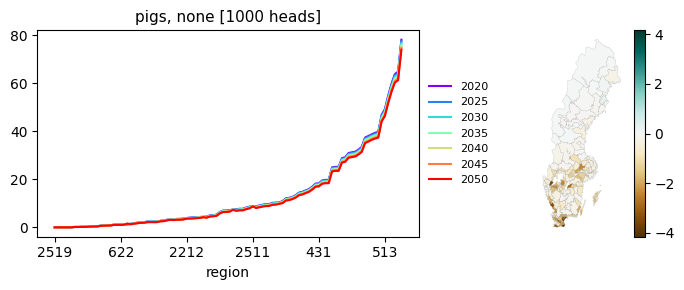

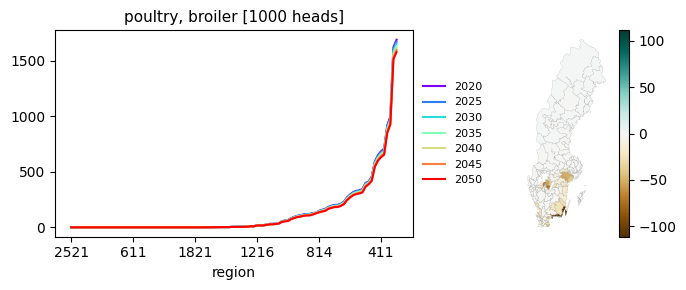

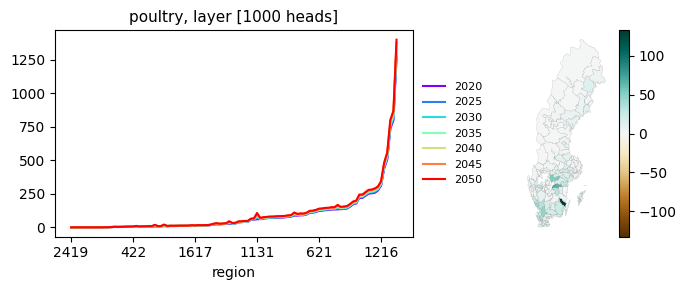

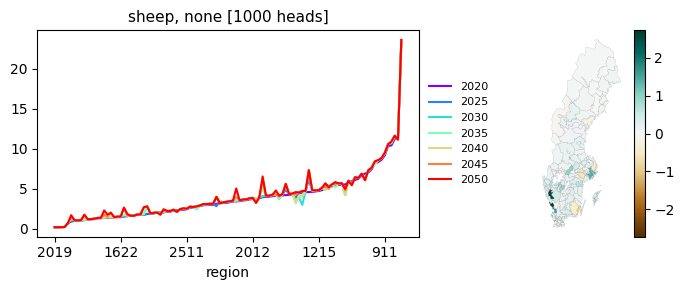

Sust50
------


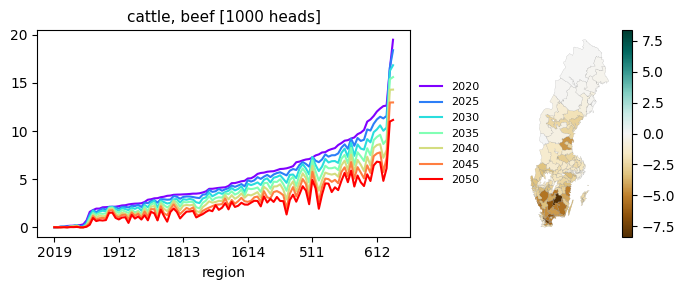

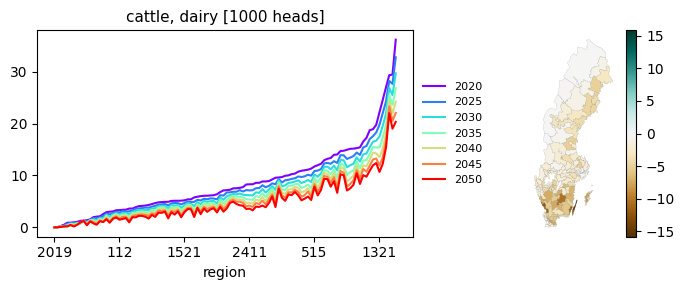

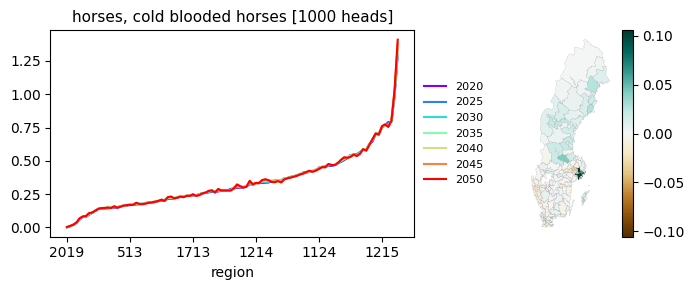

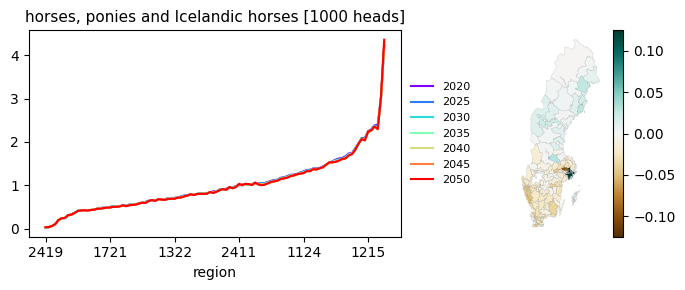

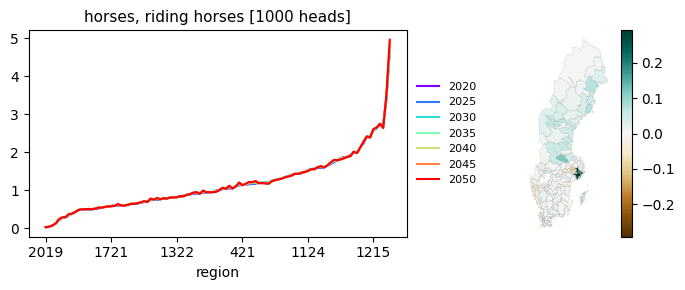

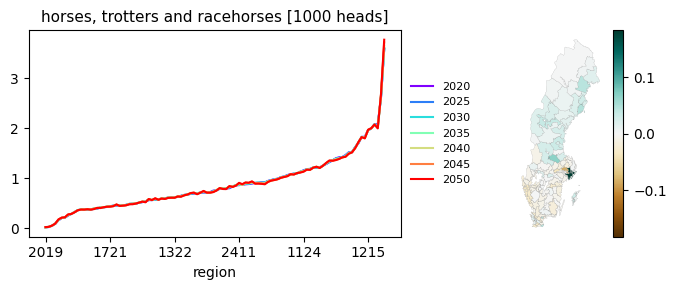

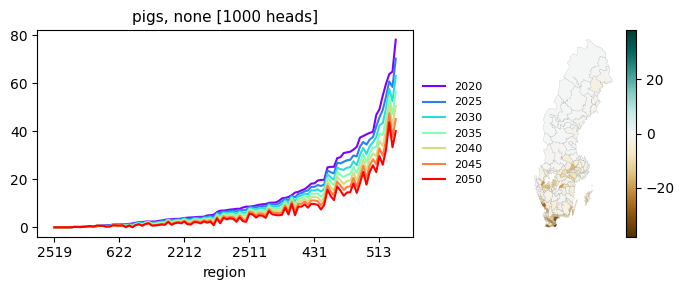

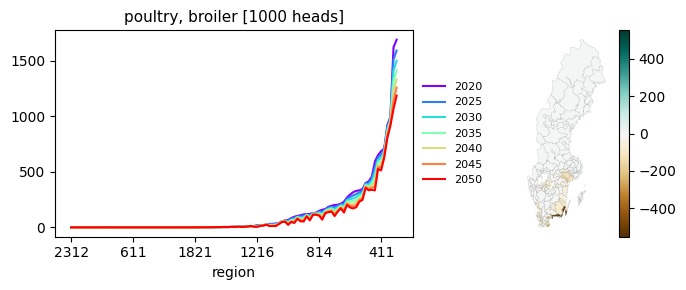

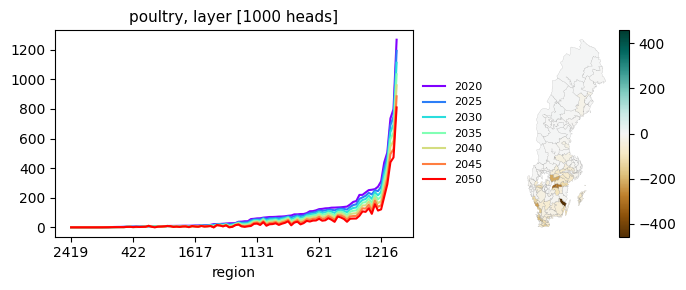

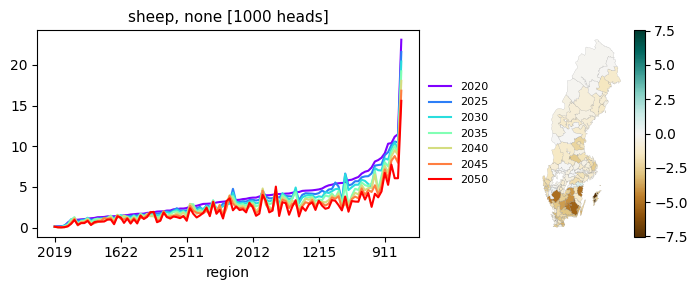

In [40]:
for scn in session.scenarios():
    print(scn)
    print('-'*len(scn))
    plot_data_ = session.get_attr('A','heads',['species','breed','region'], scn=scn).droplevel('scn').T/1000
    years = list(plot_data_.columns)

    for sp,br in plot_data_.index.droplevel('region').unique():
        plot_data = plot_data_.loc[sp,br].groupby('region').sum()
        plot_data['dif'] = (plot_data[years[-1]]-plot_data[years[0]])
        plot_data.sort_values(by=years[0], inplace=True)
    
        fig, axs = plt.subplots(1,2, figsize=(7,3), gridspec_kw={'width_ratios': [2, 1]})
        ax=axs[0]
        plot_data.plot(ax=ax, y=years, kind='line', marker='', linestyle='-', cmap='rainbow')
        # ax.set_yscale('log')
        ax.set_title(f'{sp}, {br} [1000 heads]', size=11)
        ax.legend(loc='center left', ncols=1, bbox_to_anchor=(1, 0.5), frameon=False, fontsize=8)
    
        ax=axs[1]
        lim = max(abs(plot_data['dif']))
        plot.map_from_series(
            plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
            ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
        )
        ax.axis('off')
    
        plt.tight_layout()
        plt.show()

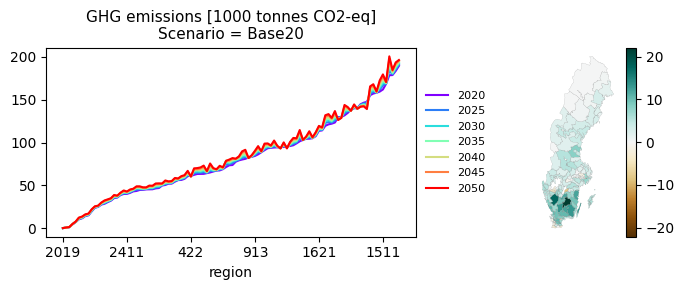

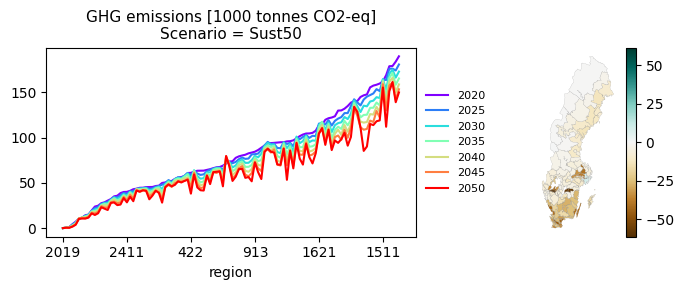

In [41]:
GHG_data = cm.get_GHG(session).T.groupby('region').sum()/1000000

for scn in session.scenarios():
    
    plot_data = GHG_data.loc[:,scn].copy()
    years = list(plot_data.columns)
    plot_data['dif'] = (plot_data[years[-1]]-plot_data[years[0]])
    plot_data.sort_values(by=years[0], inplace=True)
    
    fig, axs = plt.subplots(1,2, figsize=(7,3), gridspec_kw={'width_ratios': [2, 1]})
    ax=axs[0]
    plot_data.plot(ax=ax, y=years, kind='line', marker='', linestyle='-', cmap='rainbow')
    # ax.set_yscale('log')
    ax.set_title(f'GHG emissions [1000 tonnes CO2-eq]\nScenario = {scn}', size=11)
    ax.legend(loc='center left', ncols=1, bbox_to_anchor=(1, 0.5), frameon=False, fontsize=8)
    
    ax=axs[1]
    lim = max(abs(plot_data['dif']))
    plot.map_from_series(
        plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
        ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
    )
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Run

In [18]:
scn = 'Sust50'
year = '2050'

In [ ]:
# Instatiate Regions
regions = cm.Regions(
    par = cm.ParameterRetriever('Regions')
)

# Instantiate DemandAndConversions
demand = cm.DemandAndConversions(
    par = cm.ParameterRetriever('DemandAndConversions')
)

# Instantiate CropProduction
crops = cm.CropProduction(
    par = cm.ParameterRetriever('CropProduction'),
    index = regions.data_attr.get('x0_crops').index
)    

# Instantiate AnimalHerds
# Each AnimalHerd object is stored in an indexed pandas.Series
herds = cm.make_herds(regions)

# Instantiate WasteAndCircularity
waste = cm.WasteAndCircularity(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('WasteAndCircularity')
)

# Instantiate feed management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt')
)

# Instantiate by-product management
byprod_mgmt = cm.ByProductMgmt(
    demand = demand,
    herds = herds,
    par = cm.ParameterRetriever('ByProductMgmt')
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('ManureMgmt'),
    settings = {
        'NPK_excretion_from_balance' : True
    }
)

# Instantiate crop residue managment
crop_residue_mgmt = cm.CropResidueMgmt(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('CropResidueMgmt')
)

# Instantiate plant nutrient management
plant_nutrient_mgmt = cm.PlantNutrientMgmt(
    demand = demand,
    regions = regions,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('PlantNutrientMgmt')
)

# Instatiate machinery and energy management
machinery_and_energy_mgmt  = cm.MachineryAndEnergyMgmt(
    regions = regions,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('MachineryAndEnergyMgmt')
)

# Instatiate inputs management
inputs = cm.InputsMgmt(
    demand = demand,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('InputsMgmt')
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('GeoDistributor')
)

############################
###   RUN CALCULATIONS   ###
############################

# Update all parameter values
cm.ParameterRetriever.update_all_parameter_values(
    **session[scn],
    year = year
)

# Get region attributes
regions.calculate(verbose=True)

# Calculate food demand
demand.calculate(verbose=True)

# Calculate crops
crops.calculate(verbose=True)

# Calculate herds
for h in herds:
    h.calculate(verbose=True)

# Induce beef exports in DemandAndConversions if beef production from dairy
# systems under given demand for milk products exceeds total beef demand.
# This is to avoid not finding any solution when running the GeoDistributor.
cm.helpers.induce_beef_exports(
    demand = demand,
    herds = herds
)

# Calculate feed
feed_mgmt.calculate(verbose=True)    

# Distribute animals and crops
# Make optimisation problem
geodist.make(use_cons=[1,2,3,4,5,6,7])
# Solve optimisation problem
geodist.solve(verbose=True)

# Redistribute feeds (not yet implemented) and calculate enteric CH4 emissions
feed_mgmt.calculate2(verbose=True)

# Balance by-product demand and suply
byprod_mgmt.calculate(verbose=True)

# Calculate manure
manure_mgmt.calculate(verbose=True)

# Calculate harvest of crop residues
crop_residue_mgmt.calculate(verbose=True)

# Calculate treatment of wastes and other feedstocks
waste.calculate()

# Calculate plant nutrient management
plant_nutrient_mgmt.calculate(verbose=True)

# Calculate energy requirements
machinery_and_energy_mgmt.calculate(verbose=True)

# Calculate inputs supply chain emissions
inputs.calculate(verbose=True)

########################
###   STORE OUTPUT   ###
########################

# Store results (try again if first atempt fails)
try:
    session.store(
        scn, year,
        demand, regions, crops, waste, herds
    )
except:
    session.store(
        scn, year,
        demand, regions, crops, waste, herds
    )